## Cuadratura de Gauss - Legendre

Resultados importantes:

- El polinomio $R(x)$ es el residuo de la división de $f(x)$ entre $P_{n+1}(x)$
$$
    \frac{f(x)}{P_{n+1}(x)} = Q(x) + \frac{R(x)}{P_{n+1}(x)}
$$

- la integral de la función $f$ es igual a la integral de $R(x)$ y los puntos de cuadratura son los zeros del polinomio de Legendre de orden $n+1$
$$
    \int_{-1}^{1} f(x) dx = \int_{-1}^{1} R(x) dx \rightarrow \sum_{i=0}^n C_i R(x_i) = \sum_{i=0}^n C_i f(x_i)
$$

- Los puntos de cuadratura son los zeros del polinomio de Legendre de orden $n+1$
$$
    P_{n+1}(x_i) = 0
$$

- Los coeficientes $C_i$ se obtienen resolviendo el sistema de ecuaciones:
$$
    C_i = \frac{2}{(1-x_i^2)P_{n+1}'(x_i)}
$$

- Los polinomios de Legendre se pueden obtener recursivamente comot

$$
    (n+1)P_{n+1}(x) = (2n+1)xP_n(x) - nP_{n-1}(x)
$$

  donde, $P_0(x) = 1$ y $P_1(x) = x$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gauss_legendre(n):
    """
    Nodos y pesos de la cuadratura de Gauss-Legendre con n puntos en [-1,1].
    """
    P = np.zeros((n + 1, n + 1))            # fila i -> coefs de p_i(x)

    P[0, -1] = 1.0                 # p_0(x) = 1
    P[1, -2] = 1.0                 # p_1(x) = x

    for k in range(1, n):
        P[k+1, :] = ( ( 2*k + 1 )*np.roll( P[k,:], -1 ) - k*P[k-1,:] )/( k+1 )

    p  = P[n]
    x  = np.sort(np.roots(p))
    dp = np.polyval(np.polyder(p), x)

    return x, 2.0/((1 - x**2)*dp**2), P

In [ ]:
nmax = 10
nodos, pesos, polys = gauss_legendre(nmax)
nodes, weights = np.polynomial.legendre.leggauss(nmax)
print(np.isclose(nodes,nodes))
print(np.isclose(pesos,weights))

[ True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True]


In [ ]:
for (i, pi) in enumerate(polys):
    print(f"P{i}(x) = {np.poly1d(pi)}")

P0(x) =  
1
P1(x) =  
1 x
P2(x) =      2
1.5 x - 0.5
P3(x) =      3
2.5 x - 1.5 x
P4(x) =        4        2
4.375 x - 3.75 x + 0.375
P5(x) =        5        3
7.875 x - 8.75 x + 1.875 x
P6(x) =        6         4         2
14.44 x - 19.69 x + 6.562 x - 0.3125
P7(x) =        7         5         3
26.81 x - 43.31 x + 19.69 x - 2.188 x
P8(x) =        8         6         4         2
50.27 x - 93.84 x + 54.14 x - 9.844 x + 0.2734
P9(x) =        9         7         5         3
94.96 x - 201.1 x + 140.8 x - 36.09 x + 2.461 x
P10(x) =        10         8         6         4         2
180.4 x  - 427.3 x + 351.9 x - 117.3 x + 13.54 x - 0.2461


**Ejercicio**: Calcular numéricamente la integral
$$
    \int_{-\infty}^{\infty} e^{-x^2} dx
$$

usando la cuadratura de _Gauss-Legendre_

**Nota**: para calcular una integral impropia con limites infinitos, podemos aplicar el siguiente cambio de variable:

$$
    x = \frac{t}{1-t^2} \qquad t\in (-1,1)
$$

Con el jacobiano

$$
    dx = \frac{1+t^2}{(1-t^2)^2} dt
$$

Es decir,

$$
    \int_{-1}^{1} \exp \left( -\left[ \frac{t}{1-t^2} \right]^2 \right) \frac{1+t^2}{(1-t^2)^2} dt
$$

In [ ]:
def integral_impropia(f, n):
    t, w, _ = gauss_legendre(n)
    x = t/(1 - t**2)
    J = (1 + t**2)/(1 - t**2)**2
    return np.sum(w*J*f(x))

v_num = integral_impropia(lambda x: np.exp(-x**2), 32)
v_exact = np.sqrt(np.pi)
print(f"Error relativo de integracion: {np.abs((v_exact-v_num)/v_exact)*100:.2} %")

Error relativo de integracion: 0.00012 %


**Ejemplo**:

Una transición óptica tiene un ancho homogéneo lorentziano de semiancho $\gamma$, fijado por la vida media radiativa y la decoherencia. Sobre él se monta un ensanchamiento inhomogéneo gaussiano de desviación $\sigma$, que puede venir de dispersión de tamaños en un ensamble de puntos cuánticos, desorden en la muestra, o efecto Doppler en un gas. La línea observada es la convolución,

$$
    V (\nu) = \int_{- \infty}^{\infty} \underset{\text{inhomog} \overset{ˊ}{\text{e}} \text{neo}}{\underbrace{\frac{e^{- x^2 / 2 \sigma^2}}{\sigma \sqrt{2 \pi}}}} \text{  } \underset{\text{homog} \overset{ˊ}{\text{e}} \text{neo}}{\underbrace{\frac{\gamma / \pi}{(\nu - x)^2 + \gamma^2}}} \text{ } dx.
$$

donde $\nu$ es la frecuencia medida.

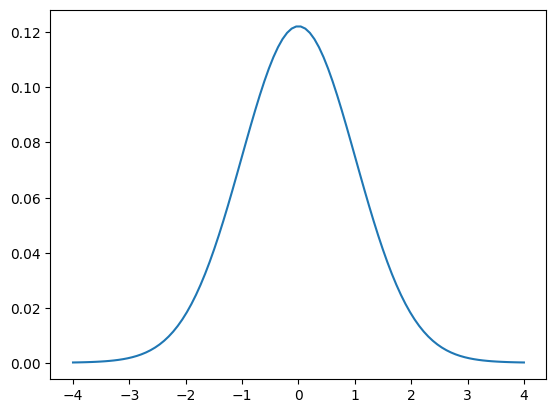

In [ ]:
def integral_impropia(f, n, s=1.0, c=0.0):
    t, w, _ = gauss_legendre(n)
    x = c + s*t/(1 - t**2)
    J = s*(1 + t**2)/(1 - t**2)**2
    return np.sum(w*J*f(x))

def v(x, nu, sigma, gama ):
    return np.exp(-x**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi))*(gama/np.pi)/( (nu-x)**2+ gama**2 )

def V(nu, sigma, gama):
    return integral_impropia( lambda x: v(x, nu, sigma, gama), 32, s = max(sigma, gama), c = nu)

gama = 0.01
sigma = 1
nu = np.linspace(-4,4,100)
y = [ V(nui,sigma, gama) for nui in nu ]
plt.plot(nu, y)
plt.show()

### Integración en dos dimensiones

Para integrar una función em dos dimensiones, usamos las integrales iteradas

$$
    \int_{c}^{d} \int_{a}^{b} f(x,y) dx \cdot dy  =  \int_{c}^{d} \left( \int_{a}^{b} f(x,y) dx \right) dy
$$

Cambiando de variable:
$$
    \begin{align}
    &=  \left( \frac{b-a}{2} \right)\int_{c}^{d} \left( \int_{-1}^{1} f\left( \frac{b-a}{2} t + \frac{b+a}{2} ,y \right) dt \right) dy  \\
    &=  \left( \frac{b-a}{2} \right) \left( \frac{d-c}{2} \right) \int_{-1}^{1} \left( \int_{-1}^{1} f\left( \frac{b-a}{2} t + \frac{b+a}{2} , \frac{d-c}{2} t' + \frac{d+c}{2} \right) dt \right) dt'
    \end{align}
$$

Entonces, aplicamos la cuadratura de _Gauss-Legendre_ para aproximar la integral:
$$
    I \approx \left( \frac{b-a}{2} \right) \left( \frac{d-c}{2} \right) \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j f\left( \frac{b-a}{2} t_i + \frac{b+a}{2} , \frac{d-c}{2} t'_j + \frac{d+c}{2} \right)
$$

Definiendo $h=\frac{b-a}{2}$ y $k=\frac{d-c}{2}$, $x_m=\frac{b+a}{2}$ y $y_m=\frac{d+c}{2}$, tenemos:

$$
    I \approx hk \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j f\left( h t_i + x_m , k t'_j + y_m \right)
$$

**Ejemplo**: Calcular la integral

$$
    \int_{0}^\pi \int_{0}^\pi \sin(x^2+y^2) dx dy
$$


In [ ]:
tn, wn, _ = gauss_legendre(15)
a, b, c, d = 0, np.pi, 0, np.pi

h = (b - a) / 2
k = (d - c) / 2

xm = (a + b) / 2
ym = (c + d) / 2

f = lambda x, y: np.sin(x**2 + y**2)

[t, tp] = np.meshgrid(tn, tn)
[w, wp] = np.meshgrid(wn, wn)
result = h * k * np.sum(w * wp * f(h * t + xm, k * tp + ym))
print(result)

0.8741681243004783


In [ ]:
import numpy as np

rng = np.random.default_rng(42)
N = 500_000

x = rng.uniform(-1.0, 1.0, N)            # caja envolvente
y = rng.uniform(-1.0, 1.52, N)

dentro = x**2 + (y - np.cbrt(x**2))**2 <= 1
p = dentro.mean()

A_caja = 2.0*2.52
area = A_caja*p

print(f"área = {area:.4f} (exacto π = {np.pi:.4f})")

área = 3.1464 (exacto π = 3.1416)


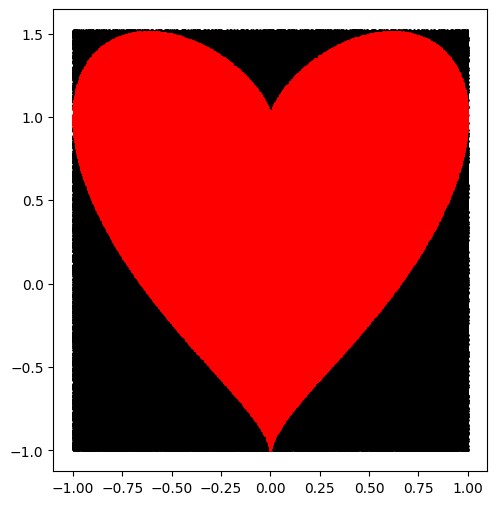

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5.6, 6.0))
ax.plot(x[~dentro], y[~dentro], ".", ms=2.0, color="black", label="fuera")
ax.plot(x[dentro],  y[dentro],  ".", ms=2.0, color="red",   label="dentro")